In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [2]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

In [3]:
# Load data
df = pd.read_csv("full_data_merged.csv", parse_dates=["date"])

# Choose 1 store and 1 family
series = df[(df["store_nbr"] == 1) & (df["family"] == "GROCERY I")]

# Aggregate daily sales
ts = series.groupby("date")["sales"].sum().sort_index()
ts = ts.asfreq('D').dropna()

In [4]:
# Train / Test split 80/20
train_size = int(len(ts) * 0.8)
train = ts[:train_size]
test  = ts[train_size:]

In [5]:
# Handle missing values
train = train.ffill()
test  = test.ffill()

In [14]:
# AR(1)
model_ar = ARIMA(train, order=(1,0,0)).fit()

# MA(1)
model_ma = ARIMA(train, order=(0,0,1)).fit()

# ARMA(1,1)
model_arma = ARIMA(train, order=(1,0,1)).fit()

# ARIMA(1,1,1)
model_arima = ARIMA(train, order=(1,1,1)).fit()

# SARIMA(1,1,1)(1,1,1,7)
model_sarima = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dat

In [15]:
# Forecast full test set
n_test = len(test)

ar_pred     = pd.Series(model_ar.forecast(steps=n_test),     index=test.index)
ma_pred     = pd.Series(model_ma.forecast(steps=n_test),     index=test.index)
arma_pred   = pd.Series(model_arma.forecast(steps=n_test),   index=test.index)
arima_pred  = pd.Series(model_arima.forecast(steps=n_test),  index=test.index)
sarima_pred = pd.Series(model_sarima.forecast(steps=n_test), index=test.index)

c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Laptop\a

In [16]:
# Forward-fill NaN in predictions 
n_test = len(test)

ar_pred = pd.Series(model_ar.forecast(steps=n_test).values, index=test.index).ffill().bfill()
ma_pred = pd.Series(model_ma.forecast(steps=n_test).values, index=test.index).ffill().bfill()
arma_pred = pd.Series(model_arma.forecast(steps=n_test).values, index=test.index).ffill().bfill()
arima_pred = pd.Series(model_arima.forecast(steps=n_test).values, index=test.index).ffill().bfill()
sarima_pred = pd.Series(model_sarima.forecast(steps=n_test).values, index=test.index).ffill().bfill()

print("NaN counts after fix:")
for name, pred in [("ar", ar_pred), ("ma", ma_pred), ("arma", arma_pred), ("arima", arima_pred), ("sarima", sarima_pred)]:
    print(f"  {name}_pred NaN: {pred.isna().sum()}")

c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Laptop\anaconda3\Lib\site-packages\stat

NaN counts after fix:
  ar_pred NaN: 0
  ma_pred NaN: 0
  arma_pred NaN: 0
  arima_pred NaN: 0
  sarima_pred NaN: 0


In [17]:
# Evaluation metrics
ar_mae, ar_rmse = evaluate(test, ar_pred)
ma_mae, ma_rmse = evaluate(test, ma_pred)
arma_mae, arma_rmse = evaluate(test, arma_pred)
arima_mae, arima_rmse = evaluate(test, arima_pred)
sarima_mae, sarima_rmse = evaluate(test, sarima_pred)

In [18]:
# Compare results, order by ascending RMSE
results = pd.DataFrame({
    "Model": ["AR(1)", "MA(1)", "ARMA(1,1)", "ARIMA(1,1,1)", "SARIMA(1,1,1)(1,1,1,7)"],
    "AIC": [
        model_ar.aic,
        model_ma.aic,
        model_arma.aic,
        model_arima.aic,
        model_sarima.aic,
    ],
    "MAE":  [ar_mae,  ma_mae,  arma_mae,  arima_mae,  sarima_mae],
    "RMSE": [ar_rmse, ma_rmse, arma_rmse, arima_rmse, sarima_rmse],
})

results = results.sort_values(by="RMSE").reset_index(drop=True)
print(results.to_string(index=False))

                 Model          AIC        MAE       RMSE
          ARIMA(1,1,1) 21403.180481 695.921647 866.627000
SARIMA(1,1,1)(1,1,1,7) 20251.785625 651.538688 884.691374
                 MA(1) 21516.343182 839.727943 971.489963
                 AR(1) 21492.149306 840.222297 971.799784
             ARMA(1,1) 21478.171532 840.586921 971.873271


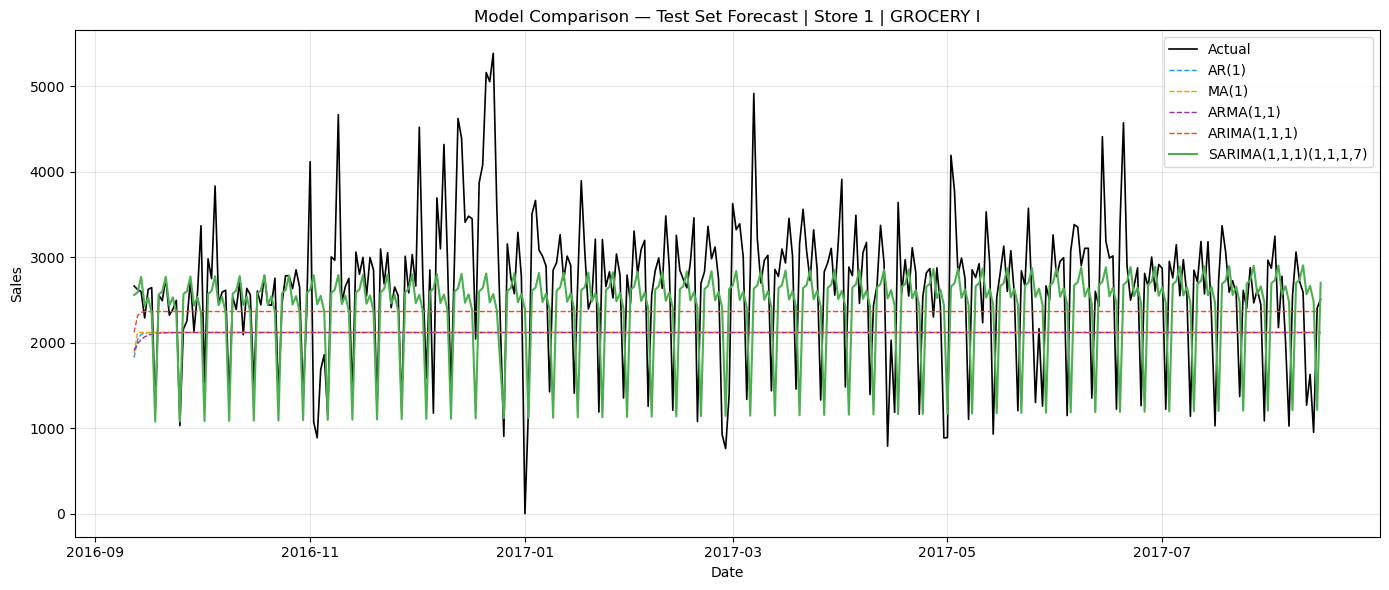

In [20]:
# Visualize forecast models on test set
plt.figure(figsize=(14, 6))
plt.plot(test.index, test,         color="black",   lw=1.2, label="Actual")
plt.plot(test.index, ar_pred,      color="#2196F3", lw=1.0, ls="--", label="AR(1)")
plt.plot(test.index, ma_pred,      color="#FF9800", lw=1.0, ls="--", label="MA(1)")
plt.plot(test.index, arma_pred,    color="#9C27B0", lw=1.0, ls="--", label="ARMA(1,1)")
plt.plot(test.index, arima_pred,   color="#F44336", lw=1.0, ls="--", label="ARIMA(1,1,1)")
plt.plot(test.index, sarima_pred,  color="#4CAF50", lw=1.5,          label="SARIMA(1,1,1)(1,1,1,7)")
plt.title("Model Comparison — Test Set Forecast | Store 1 | GROCERY I")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()